<a href="https://colab.research.google.com/github/chaitanysaraswat/Advanced-Analytics-Using-Statistics/blob/main/lecture19_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

In [5]:
df = pd.read_excel('/content/drive/MyDrive/CDAC_stats/CDAC_DataBook.xlsx', sheet_name = 'diabetes')
df = df[['Glucose','BloodPressure','Age','DietType','Outcome']]

diet_dummy = pd.get_dummies(df.DietType, drop_first=True, prefix='Diet').astype(int)
df = df.drop('DietType', axis=1)
df = pd.concat([df,diet_dummy], axis=1)

x= df.drop('Outcome', axis=1)  # column of predictors
y= df.Outcome   # column of response

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20)

dtc = DecisionTreeClassifier()
dtc.fit(x_train,y_train)

y_pred=dtc.predict(x_test)
from sklearn.metrics import confusion_matrix,classification_report

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

print(dtc.score(x_train, y_train))   # training data accuracy
print(dtc.score(x_test, y_test))    # test data accuracy

# hyperparameter tuning

param={
    'criterion':['gini','entropy', 'log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,6,7],
    'max_features':['auto','sqrt','log2'],
    'min_samples_split' : [2,3,4,5],
    'min_samples_leaf' : [2,3,4,5]
}

from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(dtc,param_grid=param,cv=5,scoring='accuracy')
grid.fit(x_train,y_train)
grid.best_params_

dtc = DecisionTreeClassifier(criterion= 'gini',
 max_depth= 5,
 max_features= 'sqrt',
 min_samples_leaf= 5,
 min_samples_split= 2,
 splitter= 'best')

dtc.fit(x_train,y_train)
print(dtc.score(x_train, y_train))   # training data accuracy
print(dtc.score(x_test, y_test))    # test data accuracy

y_pred = dtc.predict(x_test)
print(confusion_matrix(y_test,y_pred))

[[86 15]
 [14 39]]
              precision    recall  f1-score   support

           0       0.86      0.85      0.86       101
           1       0.72      0.74      0.73        53

    accuracy                           0.81       154
   macro avg       0.79      0.79      0.79       154
weighted avg       0.81      0.81      0.81       154

1.0
0.8116883116883117
0.8501628664495114
0.8376623376623377
[[88 13]
 [12 41]]


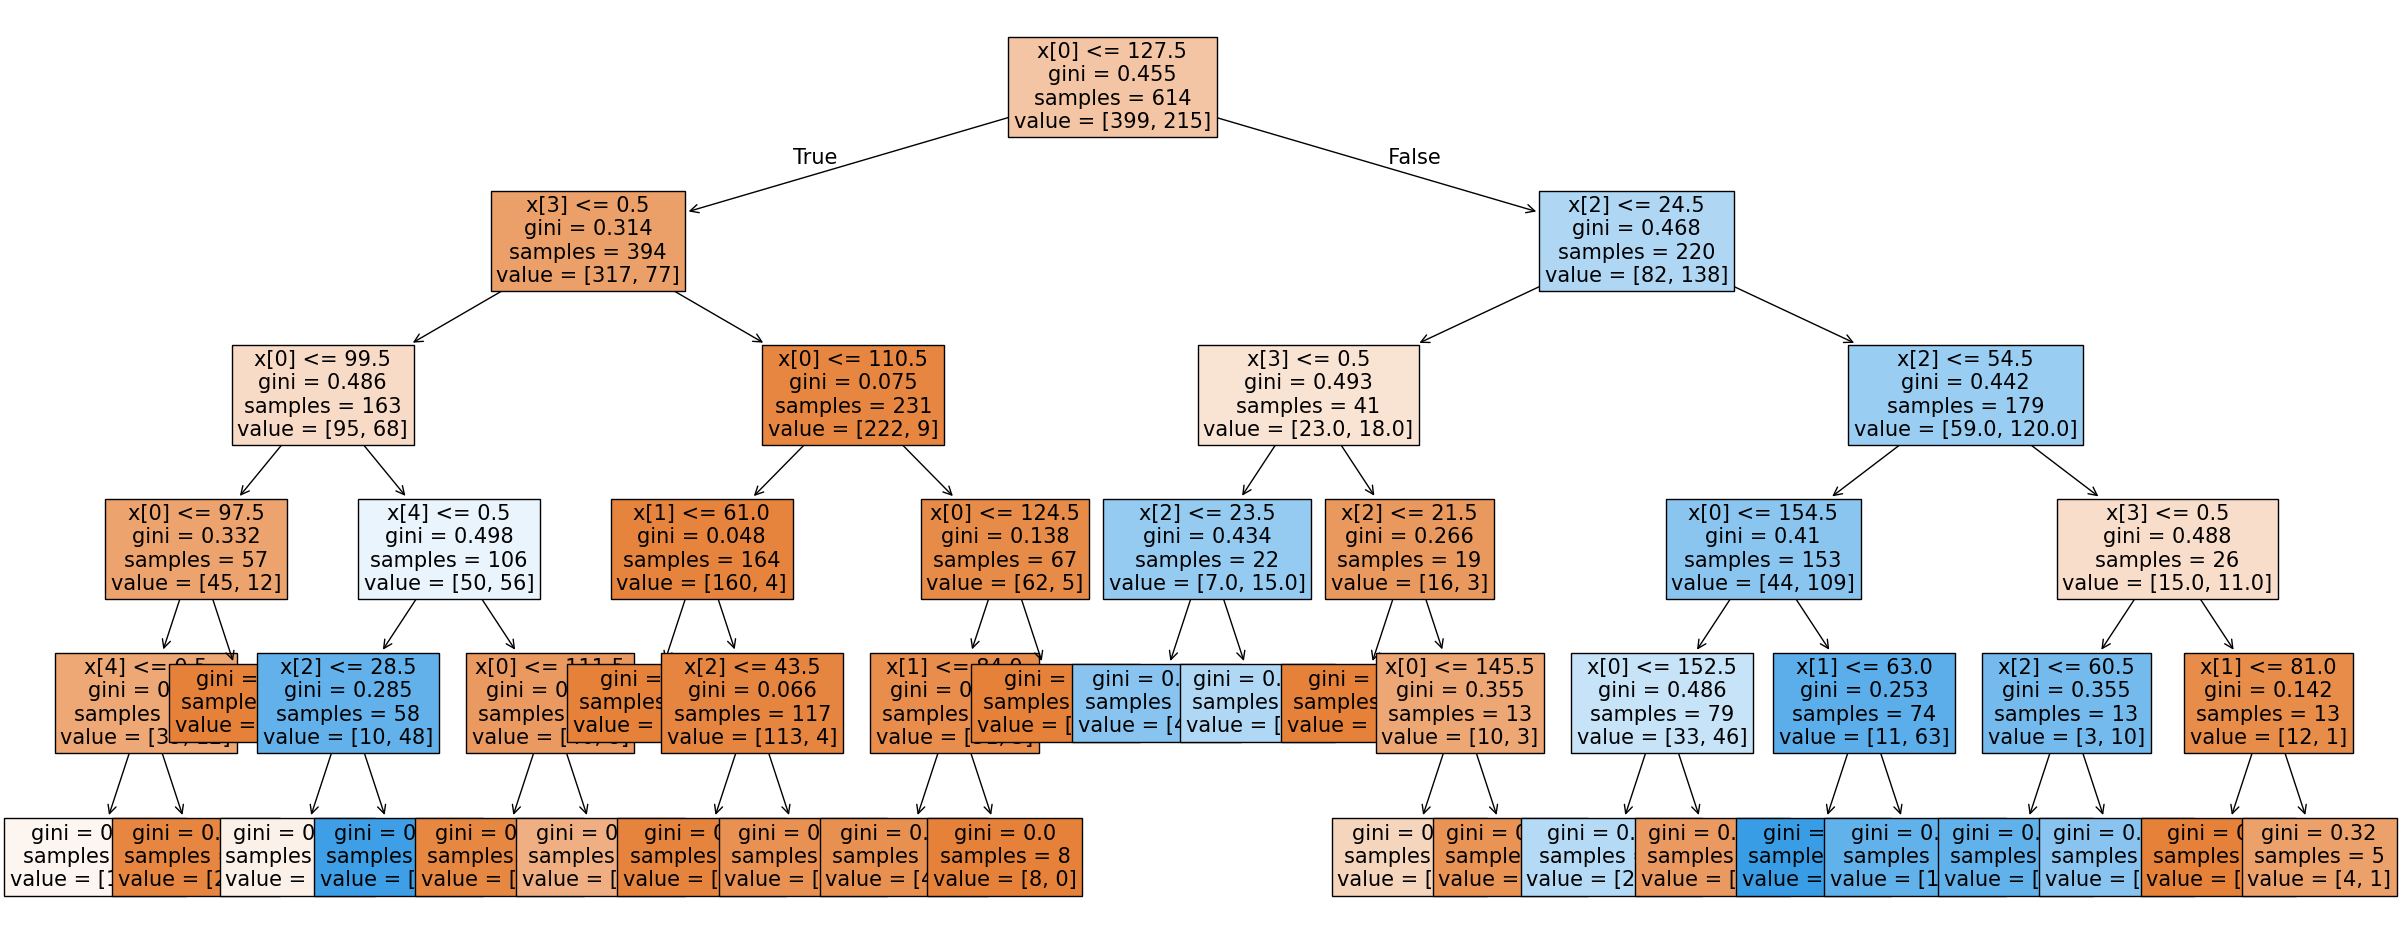

In [8]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30,12))
tree.plot_tree(
    dtc,
    filled=True,
    fontsize=15
)
plt.show()

In [9]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=50,max_depth=4)
rfc.fit(x_train,y_train)
print(rfc.score(x_train, y_train))   # training data accuracy
print(rfc.score(x_test, y_test))    # test data accuracy

0.8925081433224755
0.8831168831168831


RANDOM FOREST(N* DECISION TREE) :

- would be group of certain x no of decision tree
- the decision in random forest taken by majority or mode of response in categorical
 and in continuous response average will be taken
- random forest will have all the hyperparameter of decision tree plus one more n_estimators
---
DECISION TREE IS LESS PRONE TO OUTLIERS THAN LINEAR REGRESSION becoz best fit line will be moved to the outlier data

FOR FEATURE SELECTION WE WILL USE:

- LASSO

- MULTICOLLINARITY(VIF)

- COEFFICIENT OF VARIATION

- P VALUE USING INFERENTIAL TOOLS

- IF VARIATION IS LESS IN DATA

- EMPIRICAL TOOL: INFO GAIN

FIRST DECISION TREE IN THE SERIES OF BOOSTING MODEL IS CALLED WEAK LEARNER.

LAST DECISION TREE IS CALLED STRONG BOOSTING MODEL


---
| P1 (PREDICTION) | A (ACTUAL) | E (ERROR) | 0.1 * E (LEARNING RATE * ERROR) | P2 (NEW PRED) |
| :---: | :---: | :---: | :---: | :---: |
| 8 | 9.3 | 1.3 | 0.13 | 8.13 |
---

IF WE MAKE BIG ADJUSTMENT TO PREDICTION WE WILL LOST POINT OF MINIMA WHICH HAS LESS DIFF B/W PRED AND ACTUAL


P=P+0.1NLV

NLV=AVG RESIDUAL/HESSIAN(VARIANCE)

WHEN AND WHY NLV BIGGER:

The NLV is a ratio of how far we are from the point of minima to the variance

- if residual is high and variance is low than the value of NLV is high
 so bigger change can be made in original logic

- if residual is low and variance is high than the value of NLV is low
 so lesser change can be made in original logic


- new weight are calculated in such a way by ensuring that the rows where the error is high should get high weights

adboost continuous  gini impurity-->split-->left and right-->residual value-->alpha -->total cumulative error-->update weight-->calculative alpha and individual rsidual-->residualincreases weight increase

in adboost:
  - step 1: equal wt given to all rows and base predictions are given on avg value
  - step 2: calcualte residual for all the rows and based on residual update the weights rows with high residual will get higher wt

  - step3: the new weights wil decide the no of times or frequency goes to the next decision tree
  - step 4: in the decision tree the row with higher residual or  wt  will come more often than the less residual or wt
  (we will get large bins for for more error in continuous data)

# XGBOOST:
Loss Function:
$$
L = \frac{1}{2N}\sum_{i=1}^{N}(y_i-\hat{y}_i)^2
$$

THE FIRST DERIVATIVE OF LOSS FUCNTION IS CONSIDERED AS DEVIATION FROM THE TARGET OR RESIDUAL AND

 2ND DEIVATIVE WILL BE CONSTANT TERM

$$
Gain =
\frac{1}{2}
\left(
\frac{G_L^2}{H_L+\lambda}
+
\frac{G_R^2}{H_R+\lambda}
-
\frac{(G_L+G_R)^2}{H_L+H_R+\lambda}
\right)
-\gamma
$$

Similarity Score:
$$
w_j
=
-\frac{\sum g_i}{\sum h_i+\lambda}
$$

wj formula sigma z gi(sum of all gradient) that first derivative in numerator and in denominator is (second derivative)


# XGBoost Tree Splitting Process

### STEP 1: Calculate Base Response
- FIRST AVG = (SUM RESPONSE / COUNT OF RESPONSE)
- THAT WILL BE BASE RESPONSE

---

### STEP 2: Calculate Gradient and Hessian
- Gradient = Residual = (Pred1 - Response Column)
- Hessian will be 1 as a constant column

---

### STEP 3: Calculate Left and Right Node Statistics

#### Right Node
- Right Node Gradient = Sum of Right Node Gradients
- Right Node Hessian = Sum of Right Node Hessians

#### Left Node
- Left Node Gradient = Sum of Left Node Gradients
- Left Node Hessian = Sum of Left Node Hessians

---

### STEP 4: Calculate Leaf Weights (Wj)

#### Left Node
- Wj = Left Node Gradient / (Left Node Hessian + 1)

#### Right Node
- Wj = Right Node Gradient / (Right Node Hessian + 1)

---

### STEP 5: Calculate Gain

Assume Gamma = 0

Gain Formula:

Gain = 0.5 × (
    (Sum Left Gradient² / (Hessian Left + Lambda(1)))
    +
    (Sum Right Gradient² / (Hessian Right + Lambda(1)))
)

- If Gain calculated is negative, then split is not performed.

---

# Gamma (γ)

- Very high value of Gamma ---> Gain low or negative ---> Splitting will be negative or not possible ---> Overfitting avoided

- Gamma is too high ---> Then it may lead to Underfitting

---

# Lambda (λ)

- High value of Lambda will increase Hessian / Variance

- It will stop splitting


In [ ]:
>